In [ ]:
mport pandas as pd
import numpy as np

In [ ]:
city_daily = 'city_day_imp.csv'
df_daily = pd.read_csv(city_daily)
df_daily['Date'] = pd.to_datetime(df_daily['Date'])

In [ ]:
# WHO recommended levels(only basic pollutants)
day = {'PM2.5': 15, 'PM10': 45, 'O3': 100, 'NO2': 25, 'SO2': 40, 'CO': 4} # O3 -- 8 hrs, CO -- mg/m3
annual = {'PM2.5': 5, 'PM10': 15, 'O3': 60, 'NO2': 10, 'SO2': 0, 'CO': 0} #SO2, CO not provided(higher durations are fatal; hence no long term avg), O3 -- peak season

In [ ]:
df_daily['Year'] = df_daily['Date'].dt.year
pollutants = list(annual.keys())
df_I = df_daily.groupby(['City', 'Year'])[pollutants].mean().reset_index()
new_cols = {poll: f'{poll}_I' for poll in pollutants}
df_I.rename(columns=new_cols, inplace=True)

In [ ]:
df_I

,City,Year,PM2.5_I,PM10_I,O3_I,NO2_I,SO2_I,CO_I
0,Ahmedabad,2015,81.022438,108.228521,34.442863,25.520151,34.273822,13.589890
1,Ahmedabad,2016,70.583060,108.256421,34.531981,33.233238,37.884658,13.861230
2,Ahmedabad,2017,64.950877,108.228521,37.159000,47.329274,53.791781,25.814123
3,Ahmedabad,2018,74.737616,108.228521,36.790986,84.995479,70.342356,33.509699
4,Ahmedabad,2019,61.809452,116.426110,46.003534,90.311890,73.333205,25.885562
...,...,...,...,...,...,...,...,...
98,Visakhapatnam,2016,45.249728,87.886141,42.590707,43.083641,21.774402,1.091033
99,Visakhapatnam,2017,42.265315,93.493425,32.061370,29.935945,10.641890,0.508329
100,Visakhapatnam,2018,50.905726,117.668164,39.144767,39.010932,11.211014,0.725781
101,Visakhapatnam,2019,47.125699,115.409260,32.449562,37.281507,12.913863,0.861808


In [ ]:
for poll, threshold in annual.items():
  sub_index = poll.replace(f'{poll}_I', f'{poll}_SubI')
  if threshold !=0:
    df_I[sub_index] = df_I[f'{poll}_I'] / threshold
  else:
    df_I[sub_index] = np.nan

In [ ]:
df_I

,City,Year,PM2.5_I,PM10_I,O3_I,NO2_I,SO2_I,CO_I,PM2.5,PM10,O3,NO2,SO2,CO
0,Ahmedabad,2015,81.022438,108.228521,34.442863,25.520151,34.273822,13.589890,16.204488,7.215235,0.574048,2.552015,NaN,NaN
1,Ahmedabad,2016,70.583060,108.256421,34.531981,33.233238,37.884658,13.861230,14.116612,7.217095,0.575533,3.323324,NaN,NaN
2,Ahmedabad,2017,64.950877,108.228521,37.159000,47.329274,53.791781,25.814123,12.990175,7.215235,0.619317,4.732927,NaN,NaN
3,Ahmedabad,2018,74.737616,108.228521,36.790986,84.995479,70.342356,33.509699,14.947523,7.215235,0.613183,8.499548,NaN,NaN
4,Ahmedabad,2019,61.809452,116.426110,46.003534,90.311890,73.333205,25.885562,12.361890,7.761741,0.766726,9.031189,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98,Visakhapatnam,2016,45.249728,87.886141,42.590707,43.083641,21.774402,1.091033,9.049946,5.859076,0.709845,4.308364,NaN,NaN
99,Visakhapatnam,2017,42.265315,93.493425,32.061370,29.935945,10.641890,0.508329,8.453063,6.232895,0.534356,2.993595,NaN,NaN
100,Visakhapatnam,2018,50.905726,117.668164,39.144767,39.010932,11.211014,0.725781,10.181145,7.844544,0.652413,3.901093,NaN,NaN
101,Visakhapatnam,2019,47.125699,115.409260,32.449562,37.281507,12.913863,0.861808,9.425140,7.693951,0.540826,3.728151,NaN,NaN


In [ ]:
sub_index_cols = [col for col in list(annual.keys())]
df_I['I_Total'] = df_I[sub_index_cols].max(axis=1)

In [ ]:
df_I_final = df_I.drop(['PM2.5_I',	'PM10_I',	'O3_I',	'NO2_I',	'SO2_I',	'CO_I',	'PM2.5',	'PM10',	'O3',	'NO2',	'SO2',	'CO'], axis = 1)

In [ ]:
df_I_final

,City,Year,I_Total
0,Ahmedabad,2015,16.204488
1,Ahmedabad,2016,14.116612
2,Ahmedabad,2017,12.990175
3,Ahmedabad,2018,14.947523
4,Ahmedabad,2019,12.361890
...,...,...,...
98,Visakhapatnam,2016,9.049946
99,Visakhapatnam,2017,8.453063
100,Visakhapatnam,2018,10.181145
101,Visakhapatnam,2019,9.425140


In [ ]:
city_hour = 'city_hour_imp.csv'
df_hour = pd.read_csv(city_hour)
df_hour['Datetime'] = pd.to_datetime(df_hour['Datetime'])

In [ ]:
daily_avg = df_hour.groupby(['City', df_hour['Datetime'].dt.date])[list(day.keys())].mean().reset_index()

daily_avg.rename(columns={'Datetime': 'Date'}, inplace=True)
daily_avg['Year'] = daily_avg['Date'].apply(lambda x: x.year)

for col, threshold in day.items():
    exceeds_col = col.replace(col, f'{col}_exceeds')
    daily_avg[exceeds_col] = (daily_avg[col] > threshold).astype(int)

exceeds_cols = [col for col in daily_avg.columns if '_exceeds' in col]

daily_avg['Max_Exceedance_Day'] = daily_avg[exceeds_cols].max(axis=1)

daily_validity = df_hour.groupby(['City', df_hour['Datetime'].dt.date])['Data_Valid_Flag'].mean().reset_index()
daily_validity.rename(columns={'Datetime': 'Date'}, inplace=True)
daily_avg = pd.merge(
    daily_avg,
    daily_validity[['City', 'Date', 'Data_Valid_Flag']],
    on=['City', 'Date'],
    how='left'
)

df_valid_days = daily_avg[daily_avg['Data_Valid_Flag'] == 1].copy()

In [ ]:
df_valid_days

,City,Date,PM2.5,PM10,O3,NO2,SO2,CO,Year,PM2.5_exceeds,PM10_exceeds,O3_exceeds,NO2_exceeds,SO2_exceeds,CO_exceeds,Max_Exceedance_Day,Data_Valid_Flag
0,Ahmedabad,2015-01-01,66.790375,111.434653,117.310149,18.216522,27.644783,0.924783,2015,1,1,1,0,0,0,1,1.0
1,Ahmedabad,2015-01-02,67.973551,112.791988,38.751541,15.692083,24.552917,1.039583,2015,1,1,0,0,0,0,1,1.0
2,Ahmedabad,2015-01-03,67.973551,112.791988,30.695417,19.303333,29.065833,12.172546,2015,1,1,0,0,0,1,1,1.0
3,Ahmedabad,2015-01-04,67.973551,112.791988,36.077083,18.476250,18.594583,1.369844,2015,1,1,0,0,0,0,1,1.0
4,Ahmedabad,2015-01-05,67.973551,112.791988,39.309167,21.419583,39.334167,18.685865,2015,1,1,0,0,0,1,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29525,Visakhapatnam,2020-06-26,8.813967,32.270833,19.897083,23.271250,6.767708,0.457917,2020,0,0,0,0,0,0,0,1.0
29526,Visakhapatnam,2020-06-27,15.020833,49.510417,23.299583,25.060000,8.548750,0.473750,2020,1,1,0,1,0,0,1,1.0
29527,Visakhapatnam,2020-06-28,24.375000,74.093750,30.139167,26.060000,11.767917,0.525000,2020,1,1,0,1,0,0,1,1.0
29528,Visakhapatnam,2020-06-29,22.906250,65.729167,30.956667,29.531667,8.421250,0.478333,2020,1,1,0,1,0,0,1,1.0


In [ ]:
annual_exposure = df_valid_days.groupby(['City', 'Year']).agg(
    Total_Exceedance_Days=('Max_Exceedance_Day', 'sum'),
    Total_Valid_Days=('Max_Exceedance_Day', 'count')
).reset_index()
annual_exposure['Exposure_E'] = (
    annual_exposure['Total_Exceedance_Days'] / annual_exposure['Total_Valid_Days']
)

df_E = annual_exposure[['City', 'Year', 'Exposure_E']]

In [ ]:
df_E

,City,Year,Exposure_E
0,Ahmedabad,2015,1.000000
1,Ahmedabad,2016,1.000000
2,Ahmedabad,2017,1.000000
3,Ahmedabad,2018,1.000000
4,Ahmedabad,2019,1.000000
...,...,...,...
98,Visakhapatnam,2016,0.961749
99,Visakhapatnam,2017,0.986301
100,Visakhapatnam,2018,0.980822
101,Visakhapatnam,2019,0.983562


In [ ]:
df_risk = pd.merge(df_I_final[['City', 'Year', 'I_Total']],
                   df_E, on = ['City', 'Year'],
                   how = 'left')

In [ ]:
df_risk

,City,Year,I_Total,Exposure_E
0,Ahmedabad,2015,16.204488,1.000000
1,Ahmedabad,2016,14.116612,1.000000
2,Ahmedabad,2017,12.990175,1.000000
3,Ahmedabad,2018,14.947523,1.000000
4,Ahmedabad,2019,12.361890,1.000000
...,...,...,...,...
98,Visakhapatnam,2016,9.049946,0.961749
99,Visakhapatnam,2017,8.453063,0.986301
100,Visakhapatnam,2018,10.181145,0.980822
101,Visakhapatnam,2019,9.425140,0.983562


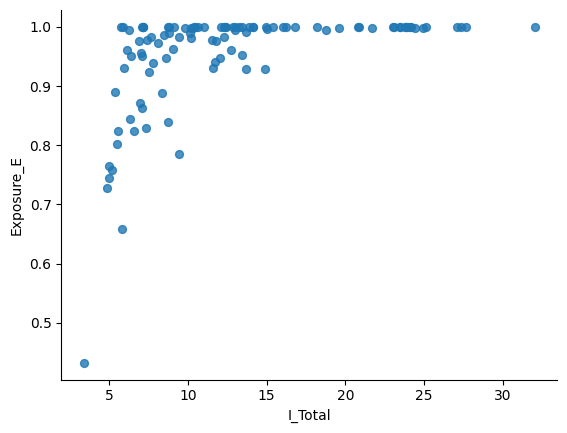

In [ ]:
from matplotlib import pyplot as plt
df_risk.plot(kind='scatter', x='I_Total', y='Exposure_E', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
df_risk['Risk_Score'] = df_risk['I_Total'] * (df_risk['Exposure_E'] + 1)

In [ ]:
df_risk

,City,Year,I_Total,Exposure_E,Risk_Score
0,Ahmedabad,2015,16.204488,1.000000,32.408975
1,Ahmedabad,2016,14.116612,1.000000,28.233224
2,Ahmedabad,2017,12.990175,1.000000,25.980351
3,Ahmedabad,2018,14.947523,1.000000,29.895047
4,Ahmedabad,2019,12.361890,1.000000,24.723781
...,...,...,...,...,...
98,Visakhapatnam,2016,9.049946,0.961749,17.753719
99,Visakhapatnam,2017,8.453063,0.986301,16.790331
100,Visakhapatnam,2018,10.181145,0.980822,20.167036
101,Visakhapatnam,2019,9.425140,0.983562,18.695346


## Improvement/Det Stats

In [ ]:
df_risk.sort_values(by = ['City', 'Year'], inplace = True)
df_risk['delta_R'] = df_risk.groupby('City')['Risk_Score'].pct_change()*100 #change in risk score YoY

In [ ]:
df_risk

,City,Year,I_Total,Exposure_E,Risk_Score,delta_R
0,Ahmedabad,2015,16.204488,1.000000,32.408975,NaN
1,Ahmedabad,2016,14.116612,1.000000,28.233224,-12.884552
2,Ahmedabad,2017,12.990175,1.000000,25.980351,-7.979511
3,Ahmedabad,2018,14.947523,1.000000,29.895047,15.067910
4,Ahmedabad,2019,12.361890,1.000000,24.723781,-17.298069
...,...,...,...,...,...,...
98,Visakhapatnam,2016,9.049946,0.961749,17.753719,NaN
99,Visakhapatnam,2017,8.453063,0.986301,16.790331,-5.426401
100,Visakhapatnam,2018,10.181145,0.980822,20.167036,20.111009
101,Visakhapatnam,2019,9.425140,0.983562,18.695346,-7.297502


In [ ]:
best = df_risk.sort_values(
    by = 'delta_R', ascending = True
).head(10)
print('Top 10 Cities with Best Year-on-Year Improvement')
best[['City', 'Year', 'delta_R']]

Top 10 Cities with Best Year-on-Year Improvement


,City,Year,delta_R
28,Chandigarh,2020,-58.293704
8,Amaravati,2018,-57.162575
22,Bhopal,2020,-42.668478
87,Patna,2020,-41.643840
69,Kolkata,2020,-36.236648
102,Visakhapatnam,2020,-33.742574
34,Chennai,2020,-32.701653
91,Talcher,2018,-32.074394
12,Amritsar,2018,-31.535308
10,Amaravati,2020,-31.040192


In [ ]:
worst = df_risk.sort_values(by='delta_R', ascending = False).head(10)
print('Top 10 Cities with Worst Year-on-Year Deterioration')
worst[['City', 'Year', 'delta_R']]

Top 10 Cities with Worst Year-on-Year Deterioration


,City,Year,delta_R
63,Jorapokhar,2018,47.795775
16,Bengaluru,2016,45.407278
95,Thiruvananthapuram,2018,43.533576
51,Guwahati,2020,28.595309
100,Visakhapatnam,2018,20.111009
26,Brajrajnagar,2020,19.580400
38,Delhi,2016,18.034661
46,Gurugram,2017,17.080177
97,Thiruvananthapuram,2020,16.189465
3,Ahmedabad,2018,15.067910


In [ ]:
df_improve = df_risk.dropna(subset=['delta_R']) # first year
df_improve = df_improve[df_improve['delta_R']<0].copy()

In [ ]:
cities_improving = df_improve.groupby('Year')['City'].nunique().reset_index()
ranked_years_by_improvement = cities_improving.sort_values(by='City', ascending = False).reset_index(drop = True)
ranked_years_by_improvement['Improvement_Rank'] = ranked_years_by_improvement.index + 1

In [ ]:
ranked_years_by_improvement

,Year,City,Improvement_Rank
0,2020,16,1
1,2019,16,2
2,2018,10,3
3,2017,8,4
4,2016,3,5


In [ ]:
df_risk.to_csv('risk_score.csv')

In [ ]:
ranked_years_by_improvement.to_csv('improvement_ranking.csv')